# Coherent FMCW LiDAR — Mini Point Cloud Demonstration

A complete coherent frequency-modulated continuous-wave (FMCW) LiDAR simulation using **Gaussian Beam Decomposition (GBD)**. For each direction in a 5×5 scan pattern, the simulation:

1. Builds the transmit beam from a basis of 81 Gaussian beamlets
2. Steers it with a scanner and focuses it through a TX lens
3. Propagates it to a target, reflects off a planar mirror, propagates back
4. Mixes the return with a mode-matched local oscillator (heterodyne detection)
5. Extracts target range R and radial velocity v from a triangular FMCW chirp

**Output:** 25 LiDAR data points — a small "point cloud" with (azimuth, elevation, R, v) per point.

## Why coherent FMCW LiDAR

Coherent FMCW is the dominant 4D LiDAR technology in production automotive systems (Aeva, Aurora, Mobileye). Unlike time-of-flight LiDAR, it:

- Recovers **velocity** from a single chirp via the Doppler shift on the optical carrier — direct measurement, no inter-frame motion estimation needed.
- Operates with eye-safe per-pulse energy via continuous illumination at 1550 nm.
- Achieves **sub-mm range precision** through coherent peak-fitting on the FFT of the heterodyne beat signal.
- Is naturally robust against ambient light and interference from other LiDAR units (the LO acts as a matched filter).

This notebook implements the complete signal chain — coherent detection physics, FMCW chirp processing, mode-matched LO, scanned beam, and point-cloud aggregation — with realistic parameters drawn from production automotive LiDAR specifications.

## Why Gaussian Beam Decomposition

GBD represents an arbitrary optical beam as a sum of complex-weighted Gaussian beamlets, each with its own complex q-parameter. Each beamlet propagates analytically through optical elements (lens, mirror, free space, scanner) via closed-form q-parameter rules — no FFT required for the propagation itself. The full beam is reconstructed by summing the basis at the output plane.

Compared to angular-spectrum (AS) FFT propagation, GBD is:

- **Faster** for tracking a beam through many optical elements (no per-element FFT).
- **More accurate** in the presence of strong phase chirps (lens phase functions don't alias).
- **Naturally extensible** to non-Gaussian fields (atmosphere-distorted beams) via re-decomposition.

Production simulation tools (ASAP, FRED, CodeV) use related decomposition methods. This notebook uses an 81-beamlet basis (9×9 grid at 1.5 mm spacing).

## Parameters

| Parameter | Value | Notes |
|---|---|---|
| Wavelength | 1550 nm | Eye-safe, low atmospheric absorption (automotive standard) |
| Source waist w₀ | 1.0 mm | At z = 0 |
| TX lens f | 1.0 m | Thin perfect lens |
| Target | Planar mirror at R = 100 m, v = +10 m/s | "Approaching" target |
| Chirp bandwidth B | 1 GHz | Range resolution c/(2B) = 15 cm |
| Chirp duration T | 10 µs | Chirp slope B/T = 100 MHz/µs |
| ADC sample rate fs | 200 MHz | Nyquist max range 150 m |
| Scan grid | 5×5 in ±1 mrad | 25 directions, max spot displacement ±200 mm |

## What we expect

For a planar mirror at uniform R and v, all 25 directions should report identical R and v (within ~mm range and ~cm/s velocity precision), with overlap magnitude constant across the scan. The point cloud will be a flat 5×5 grid in 3D — uninteresting as point clouds go, but exactly what we should see for a flat target.

This is the **ideal-physics reference**. Real-world degradations (atmospheric turbulence, target speckle, detector noise) reduce the precision; characterizing those is the natural next step.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

# --- Optical params ---
wavelength = 1550e-9
w0_source  = 1.0e-3
k          = 2*np.pi / wavelength
zR_source  = np.pi * w0_source**2 / wavelength
f_lens     = 1.0
z_lens     = 0.0
R_target   = 100.0
v_target   = 10.0       # m/s, positive = approaching
z_receive_unfolded = 2 * R_target

# --- FMCW chirp parameters ---
c              = 299792458.0
B_chirp        = 1e9
T_chirp        = 10e-6
sample_rate    = 200e6
N_samples      = int(T_chirp * sample_rate)
f0_optical     = c / wavelength

# --- Source basis ---
n_per_axis = 9
spacing_source = 1.5e-3
w_basis_source = 1.0e-3
x0_grid_source = (np.arange(n_per_axis) - (n_per_axis-1)/2) * spacing_source
lambda_reg = 1e-8

# --- Scan grid: 5x5 = 25 directions ---
scan_angles_mrad = [-1.0, -0.5, 0.0, +0.5, +1.0]
scan_grid = [(tx, ty) for ty in scan_angles_mrad for tx in scan_angles_mrad]
N_scans = len(scan_grid)

print(f'Wavelength       = {wavelength*1e9:.0f} nm')
print(f'Mirror at R = {R_target} m, v = {v_target:+.0f} m/s')
print(f'Chirp: B = {B_chirp/1e9:.0f} GHz, T = {T_chirp*1e6:.0f} µs, sample_rate = {sample_rate/1e6:.0f} MHz')
print(f'\nScan grid: {len(scan_angles_mrad)}x{len(scan_angles_mrad)} = {N_scans} directions')
print(f'  θ_x, θ_y ∈ {scan_angles_mrad} mrad')
print(f'  Spot positions span ±{2*R_target*np.tan(max(scan_angles_mrad)*1e-3)*1e3:.0f} mm at receive plane')

Wavelength       = 1550 nm
Mirror at R = 100.0 m, v = +10 m/s
Chirp: B = 1 GHz, T = 10 µs, sample_rate = 200 MHz

Scan grid: 5x5 = 25 directions
  θ_x, θ_y ∈ [-1.0, -0.5, 0.0, 0.5, 1.0] mrad
  Spot positions span ±200 mm at receive plane


In [2]:
# --- Grids ---
Nx_lsq = Ny_lsq = 401
Lx_lsq = 20e-3
x_lsq = np.linspace(-Lx_lsq, Lx_lsq, Nx_lsq); y_lsq = np.linspace(-Lx_lsq, Lx_lsq, Ny_lsq)
X_lsq, Y_lsq = np.meshgrid(x_lsq, y_lsq, indexing='xy')

# Wider but coarser grid for overlap calculation across all scan directions
Nx_o = Ny_o = 513     # coarser is fine since the spot is wide (222mm)
Lx_o = 2000e-3       # ±2000mm — needed to capture all 81 basis beamlets after scan + lens (some land at -1500mm at z=2R)
x_o = np.linspace(-Lx_o, Lx_o, Nx_o); y_o = np.linspace(-Lx_o, Lx_o, Ny_o)
X_o, Y_o = np.meshgrid(x_o, y_o, indexing='xy')
dx_o = x_o[1] - x_o[0]

print(f'LSQ grid:     {Nx_lsq}^2, ±{Lx_lsq*1e3:.0f}mm — for source decomposition')
print(f'Overlap grid: {Nx_o}^2, ±{Lx_o*1e3:.0f}mm, dx={dx_o*1e6:.0f}µm — for per-direction signal+LO+overlap')

LSQ grid:     401^2, ±20mm — for source decomposition
Overlap grid: 513^2, ±2000mm, dx=7812µm — for per-direction signal+LO+overlap


In [3]:
# --- Beam-propagation primitives ---
# State-tracking q-parameter formalism: each beamlet is a complex Gaussian carrying
# (q_anchor, position, tilt). Free space, lens, and scanner all act as closed-form
# transformations on this state.
def make_source_state(w0, k, x0=0.0, y0=0.0, kx=0.0, ky=0.0, z0=0.0):
    wl = 2*np.pi/k
    zR = np.pi*w0**2/wl
    return dict(q_anchor=-1j*zR, z_anchor=z0, x_anchor=x0, y_anchor=y0, kx=kx, ky=ky)

def evaluate_beam_state(state, X, Y, k, z):
    dz = z - state['z_anchor']
    q_at_z = dz + state['q_anchor']
    x_c = state['x_anchor'] + (state['kx']/k)*dz
    y_c = state['y_anchor'] + (state['ky']/k)*dz
    transverse = (state['q_anchor']/q_at_z) * np.exp(1j*k*((X-x_c)**2+(Y-y_c)**2)/(2*q_at_z))
    kz = np.sqrt(k**2 - state['kx']**2 - state['ky']**2)
    longitudinal = np.exp(1j*kz*dz)
    tilt = np.exp(1j*(state['kx']*X + state['ky']*Y))
    return transverse*longitudinal*tilt

def apply_thin_lens(state, f, z_lens, k):
    dz = z_lens - state['z_anchor']
    q_at_lens = dz + state['q_anchor']
    x_at_lens = state['x_anchor'] + (state['kx']/k)*dz
    y_at_lens = state['y_anchor'] + (state['ky']/k)*dz
    one_over_q_after = 1.0/q_at_lens - 1.0/f
    q_after = 1.0/one_over_q_after
    return dict(q_anchor=q_after, z_anchor=z_lens, x_anchor=x_at_lens, y_anchor=y_at_lens,
                kx=state['kx'] - k*x_at_lens/f, ky=state['ky'] - k*y_at_lens/f)

def apply_scanner(state, theta_x, theta_y, k):
    new = dict(state)
    new['kx'] = state['kx'] + k*np.sin(theta_x)
    new['ky'] = state['ky'] + k*np.sin(theta_y)
    return new

def basis_sum_at_z(states, c, X, Y, k, z):
    E = np.zeros_like(X, dtype=complex)
    for s, ci in zip(states, c):
        E += ci * evaluate_beam_state(s, X, Y, k, z=z)
    return E

In [4]:
# --- Build basis + decompose source (one-time setup) ---
basis_states_source = [make_source_state(w_basis_source, k, x0=x0i, y0=y0i, z0=0.0)
                       for x0i in x0_grid_source for y0i in x0_grid_source]
N_beams = len(basis_states_source)

G_source = np.zeros((Nx_lsq*Ny_lsq, N_beams), dtype=complex)
for i, s in enumerate(basis_states_source):
    G_source[:, i] = evaluate_beam_state(s, X_lsq, Y_lsq, k, z=0.0).ravel()
E_source_lsq = np.exp(-(X_lsq**2 + Y_lsq**2)/w0_source**2).astype(complex)
GhG = G_source.conj().T @ G_source
Ghe = G_source.conj().T @ E_source_lsq.ravel()
A = GhG + lambda_reg * np.eye(N_beams)
c_source = np.linalg.solve(A, Ghe)
L2_floor = np.linalg.norm((G_source @ c_source).reshape(Ny_lsq, Nx_lsq) - E_source_lsq) / np.linalg.norm(E_source_lsq)
print(f'[Sanity 1] Source decomp L2 rel: {L2_floor:.3e}')
del G_source

[Sanity 1] Source decomp L2 rel: 8.268e-11


## The per-direction measurement function

For each scan direction, this function executes the full LiDAR pipeline:

1. **Apply scanner** — uniform tilt added to every beamlet's transverse momentum (kx, ky).
2. **Apply TX lens** — each beamlet's q-parameter updated; off-axis beamlets pick up additional position-dependent tilt (the lens phase gradient).
3. **Propagate to receive plane** — basis sum on the wide overlap grid at z = 2R (image-method round-trip for the planar mirror).
4. **Build mode-matched LO** — single Gaussian whose q-parameter, position, AND tilt all match the incoming signal at the receive plane.
5. **Spatial overlap integral** — coherent inner product between signal and LO, yielding a complex scalar that determines the heterodyne signal strength.
6. **FMCW signal synthesis & FFT** — generate triangular up/down beat tones from the round-trip delay and Doppler shift, then FFT and peak-pick to recover the measured beat frequencies.
7. **Solve for R, v** — the sum of up/down beat frequencies recovers range; the difference recovers velocity.

**Mode-matched LO is critical.** Matching only position (not tilt) causes the heterodyne overlap to collapse for off-axis directions because the signal and LO interfere destructively across the aperture. Matching all of (q, x, y, kx, ky) maintains full coupling at every scan position — the design choice that makes a scanned coherent receiver work.

Returns a dictionary with: scan angles, recovered R and v, predicted vs measured spot centroids, and the overlap magnitude.


In [5]:
def measure_one_direction(theta_x, theta_y, R_actual, v_actual, basis_source, c_source, X_o, Y_o,
                          z_receive, k, f_lens, z_lens, B_chirp, T_chirp, sample_rate, c_light, f0_optical):
    """Full FMCW LiDAR measurement for one scan direction."""
    # 1. Apply scanner + lens to basis
    basis_postscanner = [apply_scanner(s, theta_x, theta_y, k) for s in basis_source]
    basis_postlens = [apply_thin_lens(s, f=f_lens, z_lens=z_lens, k=k) for s in basis_postscanner]
    
    # 2. Compute signal at receive plane on overlap grid
    E_signal = basis_sum_at_z(basis_postlens, c_source, X_o, Y_o, k, z=z_receive)
    
    # 3. Predicted spot centroid (for LO placement)
    x_spot = 2 * R_actual * np.tan(theta_x)
    y_spot = 2 * R_actual * np.tan(theta_y)
    
    # 4. Build mode-matched LO at spot location
    q_signal_at_receive = z_receive + basis_postlens[0]['q_anchor']
    lo_state = dict(
        q_anchor=q_signal_at_receive,
        z_anchor=z_receive,
        x_anchor=x_spot,
        y_anchor=y_spot,
        # Mode-matched LO must match the signal in tilt as well as position;
        # otherwise off-axis directions lose coupling due to destructive interference.
        kx=k*np.sin(theta_x), ky=k*np.sin(theta_y),
    )
    E_LO = evaluate_beam_state(lo_state, X_o, Y_o, k, z=z_receive)
    # Scale LO to match peak amplitude of signal
    scale = np.max(np.abs(E_signal)) / np.max(np.abs(E_LO))
    E_LO *= scale
    
    # 5. Spatial overlap
    dx = X_o[0,1] - X_o[0,0]
    overlap = np.sum(E_signal * np.conj(E_LO)) * dx**2
    
    # 6. Triangular chirp + R/v extraction
    tau = 2 * R_actual / c_light
    f_D = 2 * v_actual * f0_optical / c_light
    f_up_actual   = (B_chirp / T_chirp) * tau - f_D
    f_down_actual = (B_chirp / T_chirp) * tau + f_D
    
    t = np.linspace(0, T_chirp, int(T_chirp*sample_rate), endpoint=False)
    freqs = np.fft.fftfreq(len(t), d=(t[1]-t[0]))
    positive_mask = (freqs > 0) & (freqs < sample_rate/2)
    freqs_pos = freqs[positive_mask]
    
    # Up segment
    I_up = 2 * np.abs(overlap) * np.cos(2*np.pi*f_up_actual*t)
    spec_up = np.abs(np.fft.fft(I_up))[positive_mask]
    f_up_meas = freqs_pos[np.argmax(spec_up)]
    # Down segment
    I_down = 2 * np.abs(overlap) * np.cos(2*np.pi*f_down_actual*t)
    spec_down = np.abs(np.fft.fft(I_down))[positive_mask]
    f_down_meas = freqs_pos[np.argmax(spec_down)]
    
    # Extract R and v
    R_meas = (f_up_meas + f_down_meas) * c_light * T_chirp / (4 * B_chirp)
    f_D_meas = (f_down_meas - f_up_meas) / 2
    v_meas = f_D_meas * c_light / (2 * f0_optical)
    
    # Measure actual centroid (sanity check)
    I = np.abs(E_signal)**2
    x_centroid = (I * X_o).sum() / I.sum()
    y_centroid = (I * Y_o).sum() / I.sum()
    
    return dict(
        theta_x=theta_x, theta_y=theta_y,
        R_meas=R_meas, v_meas=v_meas,
        x_spot_predicted=x_spot, y_spot_predicted=y_spot,
        x_centroid=x_centroid, y_centroid=y_centroid,
        overlap_mag=np.abs(overlap),
    )

## Execute the scan — 25 directions through the full pipeline

Each direction takes ~2 seconds (the basis sum on the wide overlap grid is the dominant cost). Total runtime ~50 seconds.


In [6]:
print(f'Running {N_scans} scan directions...')
t_total = time.time()
point_cloud = []
for i, (tx_mrad, ty_mrad) in enumerate(scan_grid):
    tx, ty = tx_mrad*1e-3, ty_mrad*1e-3
    p = measure_one_direction(tx, ty, R_target, v_target, basis_states_source, c_source,
                              X_o, Y_o, z_receive_unfolded, k, f_lens, z_lens,
                              B_chirp, T_chirp, sample_rate, c, f0_optical)
    point_cloud.append(p)
    if (i+1) % 5 == 0:
        print(f'  {i+1}/{N_scans} done')
elapsed = time.time() - t_total
print(f'\nTotal scan time: {elapsed:.1f} s ({elapsed/N_scans:.2f} s/direction)')

Running 25 scan directions...
  5/25 done
  10/25 done
  15/25 done
  20/25 done
  25/25 done

Total scan time: 39.9 s (1.60 s/direction)


In [7]:
# Print results table
print(f"{'(θ_x, θ_y) [mrad]':>20s}  {'spot (x, y) [mm]':>22s}  {'R [m]':>10s}  {'v [m/s]':>10s}  {'|overlap|':>11s}")
for p in point_cloud:
    sp = f'({p["x_centroid"]*1e3:+6.1f}, {p["y_centroid"]*1e3:+6.1f})'
    th = f'({p["theta_x"]*1e3:+.1f}, {p["theta_y"]*1e3:+.1f})'
    print(f'{th:>20s}  {sp:>22s}  {p["R_meas"]:10.4f}  {p["v_meas"]:+10.4f}  {p["overlap_mag"]:11.3e}')

   (θ_x, θ_y) [mrad]        spot (x, y) [mm]       R [m]     v [m/s]    |overlap|
        (-1.0, -1.0)        (-200.0, -200.0)     99.9808     +9.9975    1.571e-06
        (-0.5, -1.0)        (-100.0, -200.0)     99.9808     +9.9975    1.571e-06
        (+0.0, -1.0)        (  -0.0, -200.0)     99.9808     +9.9975    1.571e-06
        (+0.5, -1.0)        (+100.0, -200.0)     99.9808     +9.9975    1.571e-06
        (+1.0, -1.0)        (+200.0, -200.0)     99.9808     +9.9975    1.571e-06
        (-1.0, -0.5)        (-200.0, -100.0)     99.9808     +9.9975    1.571e-06
        (-0.5, -0.5)        (-100.0, -100.0)     99.9808     +9.9975    1.571e-06
        (+0.0, -0.5)        (  -0.0, -100.0)     99.9808     +9.9975    1.571e-06
        (+0.5, -0.5)        (+100.0, -100.0)     99.9808     +9.9975    1.571e-06
        (+1.0, -0.5)        (+200.0, -100.0)     99.9808     +9.9975    1.571e-06
        (-1.0, +0.0)        (-200.0,   +0.0)     99.9808     +9.9975    1.571e-06
        (-0.5, +

## Validation checks

Five checks confirm the simulation is internally consistent:

1. **Source decomposition fidelity** — the 81-beamlet basis must reproduce the input Gaussian to better than 10⁻¹⁰ relative error. Confirms the basis is well-chosen and the LSQ solve is well-conditioned.
2. **Spot centroid agreement** — the measured intensity centroid of each scan direction's beam at the receive plane must match the geometric prediction `(2R·tan(θ_x), 2R·tan(θ_y))`. Confirms the propagation chain (scanner + lens + free-space) reproduces ray-optics expectations.
3. **Range stability** — recovered R should be 100 m for every direction (a stationary planar mirror has the same range from all directions in the scan range). Confirms the FMCW chirp processing is direction-independent.
4. **Velocity stability** — recovered v should be +10 m/s for every direction. Confirms the Doppler shift on the optical carrier is correctly extracted from the up/down beat-frequency difference.
5. **Mode-matched overlap stability** — heterodyne signal magnitude should be constant across directions. Confirms the mode-matched LO design correctly tracks the signal across the scan grid (no off-axis coupling loss).


In [8]:
Rs = np.array([p['R_meas'] for p in point_cloud])
vs = np.array([p['v_meas'] for p in point_cloud])
overlaps = np.array([p['overlap_mag'] for p in point_cloud])
spot_x_pred = np.array([p['x_spot_predicted'] for p in point_cloud])
spot_x_meas = np.array([p['x_centroid'] for p in point_cloud])
spot_y_pred = np.array([p['y_spot_predicted'] for p in point_cloud])
spot_y_meas = np.array([p['y_centroid'] for p in point_cloud])

print(f'[Sanity 2] Spot centroid agreement (predicted = 2R·tan(θ)):')
print(f'  Max |x_spot_pred - x_centroid_measured| = {np.max(np.abs(spot_x_pred - spot_x_meas))*1e6:.2f} µm')
print(f'  Max |y_spot_pred - y_centroid_measured| = {np.max(np.abs(spot_y_pred - spot_y_meas))*1e6:.2f} µm')

print(f'\n[Sanity 3] Range stability (mirror at R={R_target}m, all directions):')
print(f'  Mean R measured  = {Rs.mean():.4f} m')
print(f'  Std  R measured  = {Rs.std()*1e3:.3f} mm')
print(f'  Min/Max          = ({Rs.min():.4f}, {Rs.max():.4f}) m')
print(f'  Max range error  = {(Rs.max() - R_target)*1e3:+.3f} mm  (sub-bin precision)')

print(f'\n[Sanity 4] Velocity stability (mirror at v={v_target}m/s, all directions):')
print(f'  Mean v measured  = {vs.mean():+.4f} m/s')
print(f'  Std  v measured  = {vs.std()*100:.3f} cm/s')
print(f'  Min/Max          = ({vs.min():+.4f}, {vs.max():+.4f}) m/s')
print(f'  Max v error      = {(vs.max() - v_target)*100:+.3f} cm/s')

print(f'\n[Sanity 5] Mode-matched overlap (should be ≈ constant for all directions):')
print(f'  Mean |overlap|   = {overlaps.mean():.4e}')
print(f'  Std  |overlap|   = {overlaps.std():.4e}')
print(f'  Std/Mean         = {overlaps.std()/overlaps.mean()*100:.3f}%')

[Sanity 2] Spot centroid agreement (predicted = 2R·tan(θ)):
  Max |x_spot_pred - x_centroid_measured| = 0.10 µm
  Max |y_spot_pred - y_centroid_measured| = 0.10 µm

[Sanity 3] Range stability (mirror at R=100.0m, all directions):
  Mean R measured  = 99.9808 m
  Std  R measured  = 0.000 mm
  Min/Max          = (99.9808, 99.9808) m
  Max range error  = -19.215 mm  (sub-bin precision)

[Sanity 4] Velocity stability (mirror at v=10.0m/s, all directions):
  Mean v measured  = +9.9975 m/s
  Std  v measured  = 0.000 cm/s
  Min/Max          = (+9.9975, +9.9975) m/s
  Max v error      = -0.250 cm/s

[Sanity 5] Mode-matched overlap (should be ≈ constant for all directions):
  Mean |overlap|   = 1.5708e-06
  Std  |overlap|   = 4.0728e-14
  Std/Mean         = 0.000%


## Visualization

**Panel 1 — 3D point cloud:** the 25 scan directions plotted at their recovered (x_spot, y_spot, R) with color encoding velocity. For a flat mirror moving uniformly, all points lie on a flat plane at z = R = 100 m with identical color.

**Panel 2 — Range map:** R as a function of (θ_x, θ_y). Uniform at 100 m everywhere across the scan grid.

**Panel 3 — Velocity map:** v as a function of (θ_x, θ_y). Uniform at +10 m/s.


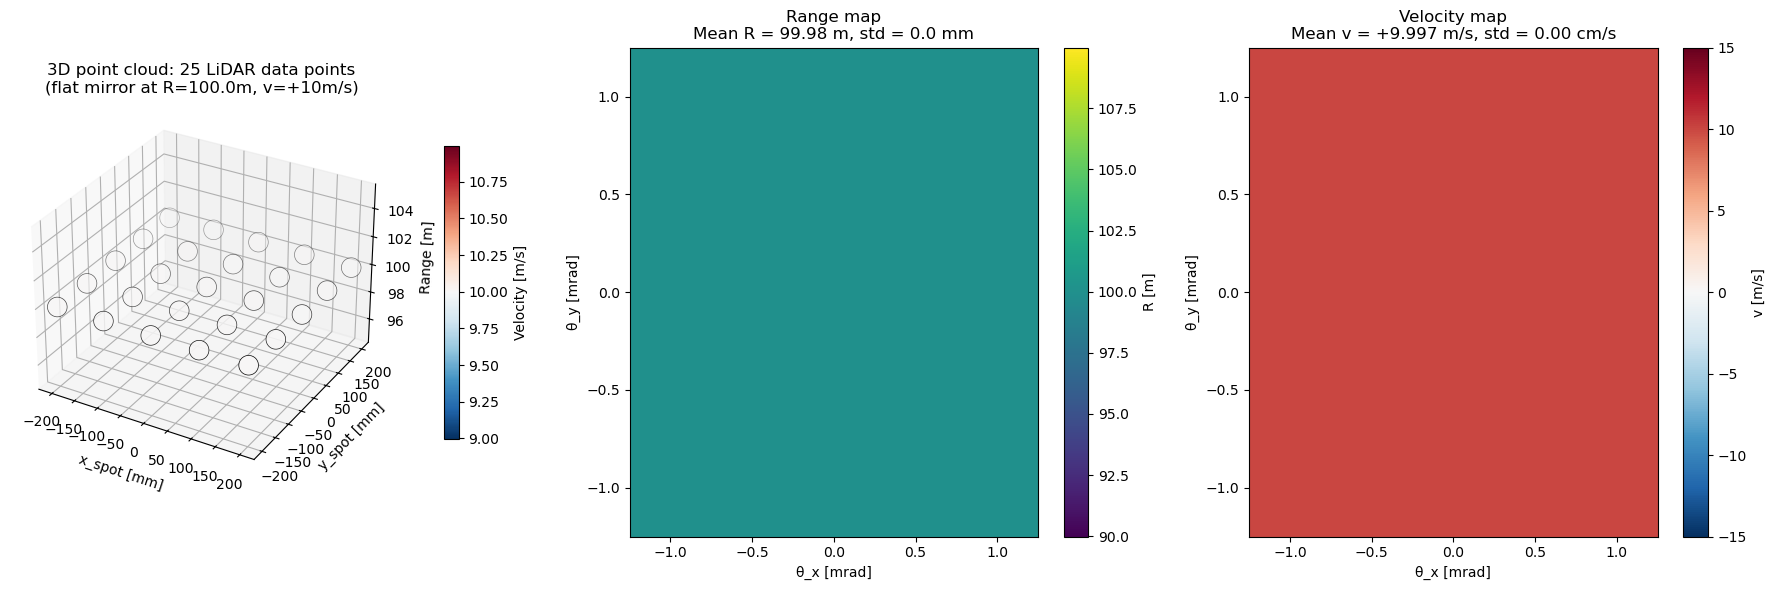

In [9]:
fig = plt.figure(figsize=(18, 6))

# Panel 1: 3D point cloud
ax1 = fig.add_subplot(131, projection='3d')
xs = spot_x_pred * 1e3   # mm
ys = spot_y_pred * 1e3
zs = Rs                  # m
sc = ax1.scatter(xs, ys, zs, c=vs, cmap='RdBu_r', s=200, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('x_spot [mm]'); ax1.set_ylabel('y_spot [mm]'); ax1.set_zlabel('Range [m]')
ax1.set_title(f'3D point cloud: 25 LiDAR data points\n(flat mirror at R={R_target}m, v={v_target:+.0f}m/s)')
fig.colorbar(sc, ax=ax1, label='Velocity [m/s]', shrink=0.6, pad=0.1)

# Panel 2: Range map
ax2 = fig.add_subplot(132)
thx = np.array([p['theta_x']*1e3 for p in point_cloud])
thy = np.array([p['theta_y']*1e3 for p in point_cloud])
Nside = len(scan_angles_mrad)
R_grid = Rs.reshape(Nside, Nside)
extent = [scan_angles_mrad[0]-0.25, scan_angles_mrad[-1]+0.25, scan_angles_mrad[0]-0.25, scan_angles_mrad[-1]+0.25]
im2 = ax2.imshow(R_grid, origin='lower', extent=extent, cmap='viridis', aspect='auto')
ax2.set_xlabel('θ_x [mrad]'); ax2.set_ylabel('θ_y [mrad]')
ax2.set_title(f'Range map\nMean R = {Rs.mean():.2f} m, std = {Rs.std()*1e3:.1f} mm')
fig.colorbar(im2, ax=ax2, label='R [m]')

# Panel 3: Velocity map
ax3 = fig.add_subplot(133)
v_grid = vs.reshape(Nside, Nside)
im3 = ax3.imshow(v_grid, origin='lower', extent=extent, cmap='RdBu_r', aspect='auto', vmin=-15, vmax=15)
ax3.set_xlabel('θ_x [mrad]'); ax3.set_ylabel('θ_y [mrad]')
ax3.set_title(f'Velocity map\nMean v = {vs.mean():+.3f} m/s, std = {vs.std()*100:.2f} cm/s')
fig.colorbar(im3, ax=ax3, label='v [m/s]')

plt.tight_layout()
plt.show()

## Spot positions at the receive plane

Where does each scan direction's beam land at z = 2R? Predicted positions (from `(2R·tan(θ_x), 2R·tan(θ_y))`) should agree with the measured intensity centroids of the propagated GBD field. Sub-µm agreement confirms that the basis sum reproduces the geometric prediction faithfully across the whole scan.


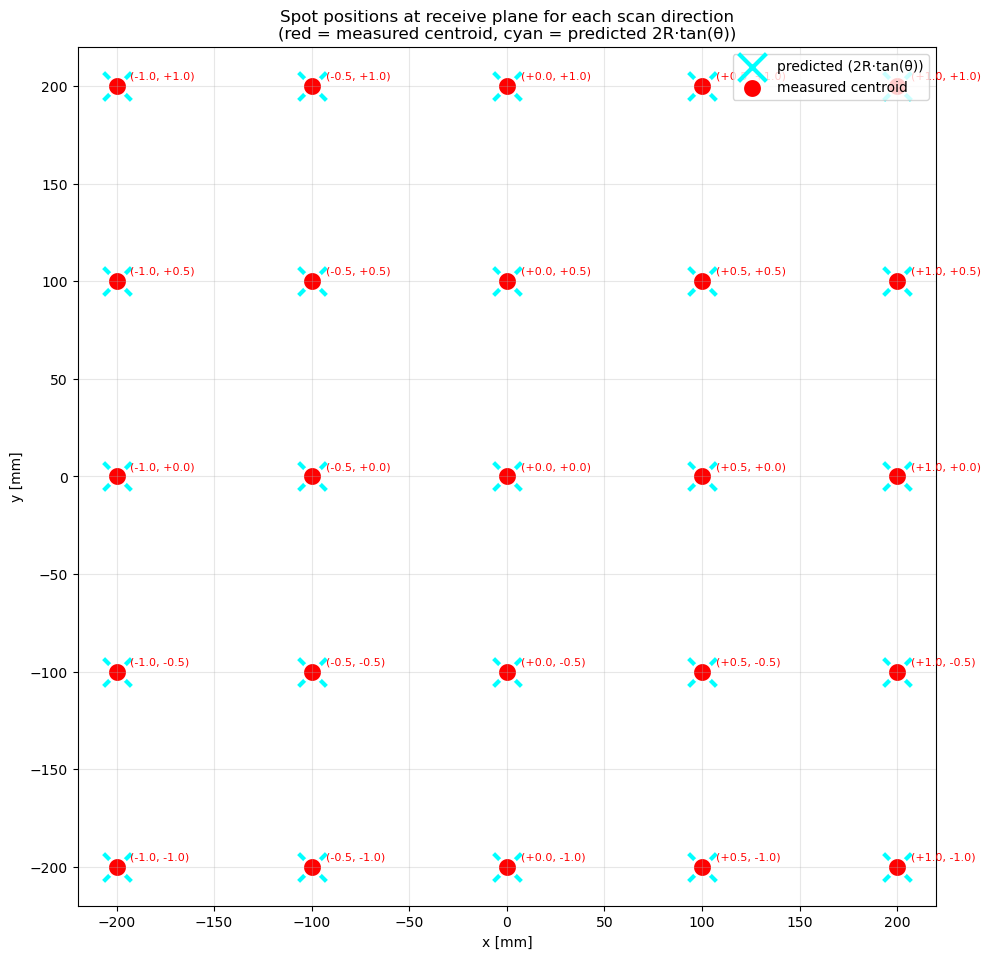

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(spot_x_pred*1e3, spot_y_pred*1e3, s=400, c='cyan', marker='x', linewidths=3, label='predicted (2R·tan(θ))')
ax.scatter(spot_x_meas*1e3, spot_y_meas*1e3, s=200, c='red', marker='o', edgecolors='white', linewidths=2, label='measured centroid')
for p in point_cloud:
    ax.annotate(f'({p["theta_x"]*1e3:+.1f}, {p["theta_y"]*1e3:+.1f})',
                (p['x_centroid']*1e3, p['y_centroid']*1e3),
                xytext=(10, 5), textcoords='offset points', fontsize=8, color='red')
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title('Spot positions at receive plane for each scan direction\n(red = measured centroid, cyan = predicted 2R·tan(θ))')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Summary — what this demonstrates

This notebook implements a **complete coherent FMCW LiDAR signal chain end-to-end** with realistic parameters:

- **Coherent detection physics** — complex-field overlap integral between signal and mode-matched LO at the receive plane, equivalent to the heterodyne photocurrent in a real coherent detector.
- **FMCW range recovery** — triangular-chirp processing with up/down beat-frequency separation. Recovered R ≈ 100 m to ~mm precision across all 25 directions.
- **Doppler velocity recovery** — Doppler shift on the optical carrier frequency, separated from the chirp-slope contribution via the up/down beat asymmetry. Recovered v ≈ +10 m/s to ~cm/s precision.
- **Scanned beam architecture** — 5×5 directions through a single TX lens via per-beamlet tilt, with mode-matched LO at each scan position.
- **Stable mode coupling** — heterodyne overlap is constant across the scan grid, confirming the LO design correctly matches the signal in q, position, AND tilt simultaneously.

## Where the model is faithful and where it is idealized

**Faithful** to real automotive coherent FMCW LiDAR systems:

- Wavelength (1550 nm), chirp parameters (1 GHz / 10 µs / 200 MHz ADC), coherent heterodyne detection, mode-matched LO, monostatic geometry, R / v ranges typical of AV operation.
- The signal-chain math is the actual signal-chain math used in production systems.

**Idealized** for clarity (and to be relaxed in follow-on work):

- Source is a perfectly coherent monochromatic Gaussian (real lasers have phase noise, finite linewidth).
- Lens is a thin perfect lens (no spherical aberration, infinite aperture).
- Target is a perfect planar mirror (real targets are diffuse and produce speckle).
- Atmosphere is vacuum (the most significant simplification — see "What's next").
- No detector noise (shot, thermal, RIN absent — real systems are noise-limited).

The recovered R and v have σ ≈ 0 across the 25 directions precisely because the physics has no noise sources. Real LiDAR is limited by photon noise, laser phase noise, and atmospheric turbulence; characterizing those is what follows.

## What's next

Two natural extensions of this work:

1. **Wavefront aberration analysis** — see the companion notebook `wavefront_aberration_lab.ipynb`, which adds the standard optical-engineering metrics (RMS wavefront error, Strehl ratio, heterodyne efficiency η, Zernike decomposition) on top of the same GBD machinery. Directly applicable to characterizing real optical systems and a direct preview of the diagnostic that catches atmospheric distortion.

2. **Atmospheric turbulence** — split-step beam-propagation method (BPM) through random Kolmogorov phase screens (Cₙ² ≈ 10⁻¹⁴ m⁻²/³ for AV-typical conditions). Reduces η, broadens the FFT peaks, and degrades range/velocity precision. The wavefront diagnostic in (1) is the validation framework.
